# RB and spikes coocurrance - plots of RB with spikes, correlation, example activation

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code_new_filter')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean_copy/code_new_filter/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] #,'A']
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
AREAS = params_analysis['areas']

AREA = 'V12'
SEL_TH = params_analysis['select_th']
DUAL_TH = [2.5,3.5]

## Functions

In [4]:
def corr_list_one_arr(env_arr,spikes_arr,bin_size=10,num_bins_win=100):
    """
    Return list of Pearson corr. values for 1 s windows.
    The input is an array, which is further summed up, binned, and correlation is computed on windows of num_bins_win.
    """
    env_tot = np.sum(env_arr,axis=0)
    sp_tot = np.sum(spikes_arr,axis=0)
    len_rec_ms = env_tot.shape[0]
    len_rec_s = int(len_rec_ms//1000)
    # cutting out the right side that does not fit into bins
    env_tot = env_tot[:len_rec_s*1000]
    sp_tot = sp_tot[:len_rec_s*1000]
    #print(env_tot.shape)
    # binning
    env_tot = env_tot.reshape(-1, bin_size).sum(axis=1)
    sp_tot = sp_tot.reshape(-1, bin_size).sum(axis=1)
    #print(env_tot.shape)
    corr_list = []
    for i in range(len_rec_s):
        r, _ = pearsonr(env_tot[i*num_bins_win:(i+1)*num_bins_win],sp_tot[i*num_bins_win:(i+1)*num_bins_win])
        corr_list.append(r) 
    return corr_list

In [5]:
def moving_average(data, window_size):
    """
    Moving average.
    """
    window = np.ones(np.int64(window_size))/float(window_size)
    return np.convolve(data, window, mode='same')

In [6]:
def plot_example_activity(env_arr,spikes_arr,cl_arr,set_params={}):
    """
    Plotting example of spiking per class and env. activity.
    """
    #sigma_spikes = set_params['sigma_spikes']
    #sigma_env = set_params['sigma_env']
    win_spikes = set_params['moving_win_width']
    win_env = set_params['moving_win_width']
    cell_classes = set_params['final_classes']
    class_color = set_params['class_colors']

    sp_dict = {}
    for cl in cell_classes:
        cl_mask = cl_arr==cl
        #print(f'Num. cells {cl}: {np.sum(cl_mask)}')
        sp_dict[cl] = np.sum(spikes_arr[cl_mask],axis=0)
        if win_spikes is not None:  # smoothing
            sp_dict[cl] = moving_average(sp_dict[cl],win_spikes)
        sp_dict[cl] = (sp_dict[cl]-np.min(sp_dict[cl]))/(np.max(sp_dict[cl])-np.min(sp_dict[cl]))  # normalisation

    spikes_total = np.sum(spikes_arr,axis=0)
    env_total = np.sum(env_arr,axis=0)
    if win_env is not None:
        env_total = moving_average(env_total,win_env)
    env_total =  (env_total-np.min(env_total))/(np.max(env_total)-np.min(env_total))
    if win_spikes is not None:
        spikes_total = moving_average(spikes_total,win_spikes)
    spikes_total =  (spikes_total-np.min(spikes_total))/(np.max(spikes_total)-np.min(spikes_total))
    
    fig, ax = plt.subplots()
    fig.set_figwidth(10)
    fig.set_figheight(6)

    N=250
    x_pos = range(len(env_total))
    # TOTAL ACTIVITY
    ax.plot(x_pos[N:-N],env_total[N:-N]*1.8,alpha=0.6,color='k',label='Total RB env.')
    ax.plot(x_pos[N:-N],spikes_total[N:-N]*1.8,alpha=0.7,color='purple',label='Total num. spikes')
    
    # INIDIVIDUAL CLASSES ACTIVITY
    shift = -1
    norm_factor = 0.6
    for idx, cl in enumerate(cell_classes):
        ax.fill_between(x_pos[N:-N],shift,sp_dict[cl][N:-N]*norm_factor+shift,color=CLASS_COLORS[cl],alpha=0.3)
        ax.plot(x_pos[N:-N],sp_dict[cl][N:-N]*norm_factor+shift,color=CLASS_COLORS[cl],alpha=0.9)
        shift-=0.8

    for sp in ['top','right','left']:
        ax.spines[sp].set_visible(False)
    ax.set_yticks([])

    xticks_ms = ax.get_xticks()
    xticks_s = xticks_ms/1000
    ax.set_xticks(xticks_ms)
    ax.set_xticklabels([f'{x:.1f}' for x in xticks_s],fontsize=12)

    ax.set_xlabel('Time [s]',fontsize=14)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()
    plt.close()
    return

In [7]:
def find_close_triplets(nums, low_threshold = 7, hi_threshold=12):
    """
    Auxiliary function for finding repeating spiking.
    """
    result_triplet = []
    result_leader = []
    for i in range(len(nums) - 2):
        if (low_threshold < nums[i+1] - nums[i] and
            nums[i+1] - nums[i] < hi_threshold and 
            low_threshold < nums[i+2] - nums[i+1] and 
            nums[i+2] - nums[i+1] < hi_threshold):
            result_triplet.append((nums[i], nums[i+1], nums[i+2]))
            result_leader.append(nums[i])
    return result_triplet, result_leader

In [8]:
def find_classes_cells(spike_block,sua_df):
    """
    For a spike block, returns the list of classes corresponding to final class of each of the cells.
    """
    num_cells = len(spike_block.segments[0].spiketrains)
    cl_list = []
    for idx in range(num_cells):
        sp_train = spike_block.segments[0].spiketrains[idx]
        cell_name = sp_train.annotations['nix_name']
        df_cell = sua_df[sua_df['cell_name']==cell_name]
        if len(df_cell['final_class'])==1:
            cl_list.append(df_cell['final_class'])
        else:
            pass
    return cl_list

In [9]:
def find_channels_cells(spike_block,sua_df):
    """
    For a spike block, returns the list of channel corresponding to index in RB or LFP file.
    """
    num_cells = len(spike_block.segments[0].spiketrains)
    cl_list = []
    for idx in range(num_cells):
        sp_train = spike_block.segments[0].spiketrains[idx]
        cell_name = sp_train.annotations['nix_name']
        df_cell = sua_df[sua_df['cell_name']==cell_name]
        if len(df_cell['channel_order'])==1:
            cl_list.append(df_cell['channel_order'])
        else:
            pass
    return cl_list

## Plotting - illustration of activity, ripples and spikes of different types

### Data loading

In [10]:
# Example for monkey L
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]

In [11]:
# Ripple band envelope
arr_list = []
for arr in range(16):
    if AREAS[MONKEY][arr] in ['V1','V2']:
        print(arr)
        aux_bl = load_block(MONKEY,arr+1,'RS','RB',DATE,data_folder=DATA_FOLDER)
        aux_env = sig_block_to_arr(aux_bl,'RB_envelope_norm')
        # Additional lowpass filter
        aux_env = elephant.signal_processing.butter(aux_env, highpass_frequency=None, lowpass_frequency=40, 
                                                    order=6, filter_function='sosfiltfilt',sampling_frequency=1000, axis=-1)
        # renormalize, because we filtered again
        aux_env = aux_env/aux_env.std(axis=1,keepdims=True)
        arr_list.append(aux_env)

0
3
4
5
6
7
8
9
10
11
12
13
14
15


In [12]:
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)

In [13]:
# Spikes
sp_arr_list = []
cl_list = []
for arr in range(16):
    if AREAS[MONKEY][arr] in ['V1','V2']:
        print(arr)
        aux_bl = load_block(MONKEY,arr+1,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
        aux_arr = spike_block_to_arr(aux_bl)
        sp_arr_list.append(aux_arr)
        cl_list.append(np.array(find_classes_cells(aux_bl,df_sua)))

0
3
4
5
6
7
8
9
10
11
12
13
14
15


### Plotting

In [14]:
# pooling data from all arrays in V1
env_arr = np.vstack(arr_list)
cl_arr = np.vstack(cl_list)[:,0]
spikes_arr = np.vstack(sp_arr_list)

In [15]:
set_params = {}
#set_params['sigma_spikes'] = 50
#set_params['sigma_env'] = 10
set_params['moving_win_width'] = 100
set_params['final_classes'] = FINAL_CLASSES
set_params['class_colors'] = CLASS_COLORS

In [16]:
WIN_WIDTH = 15*1000

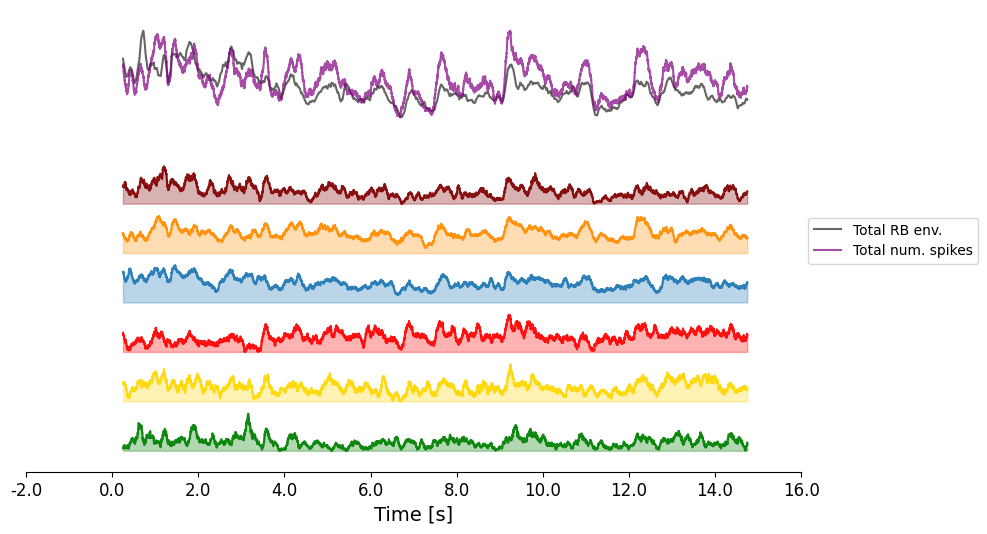

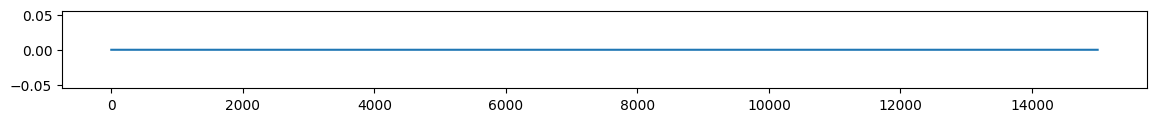

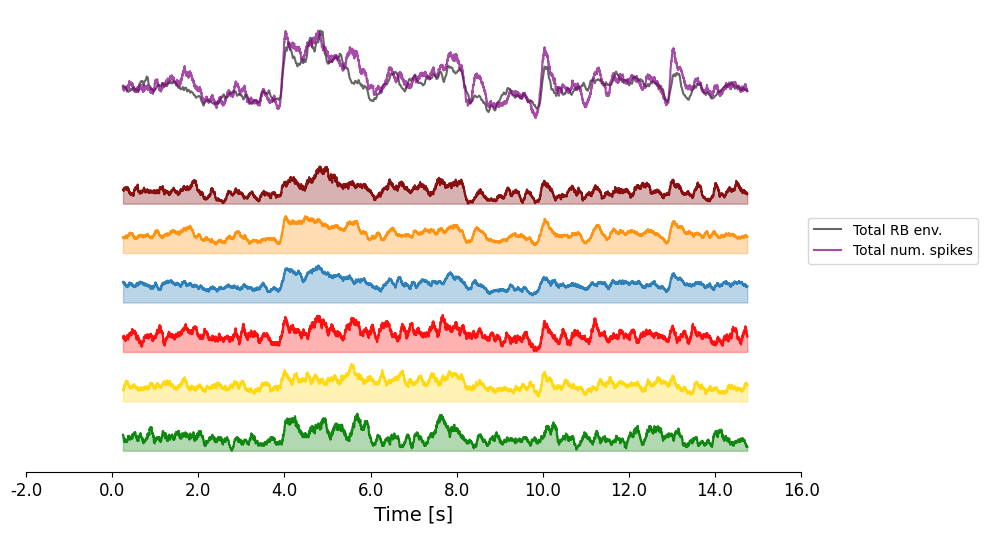

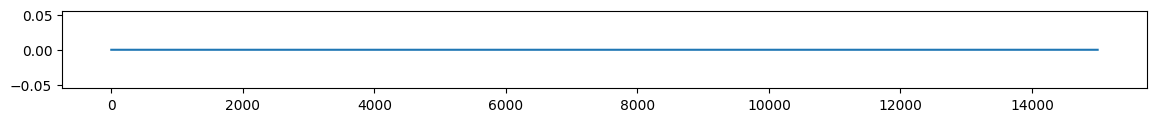

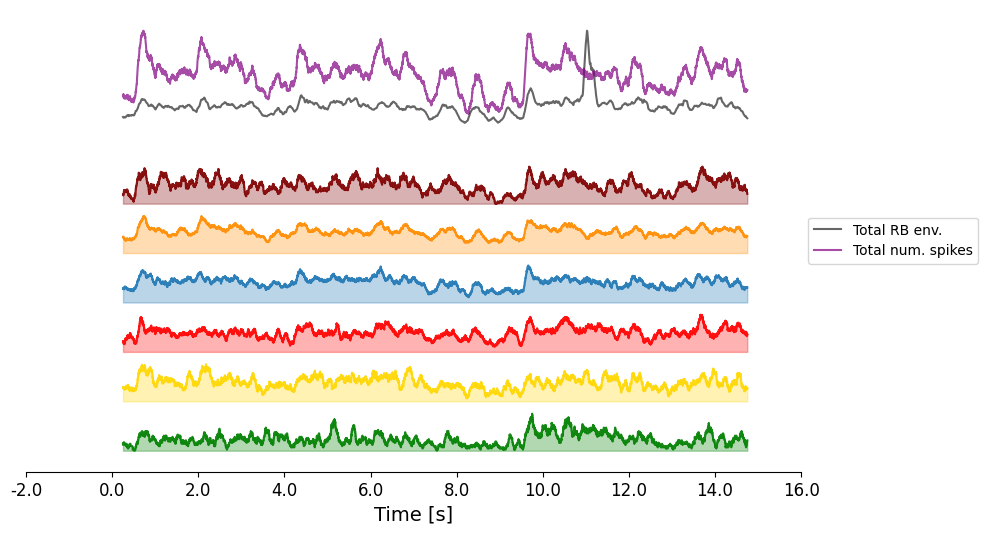

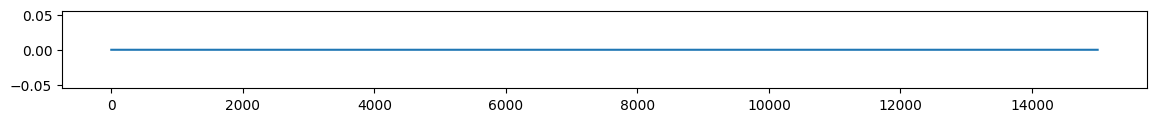

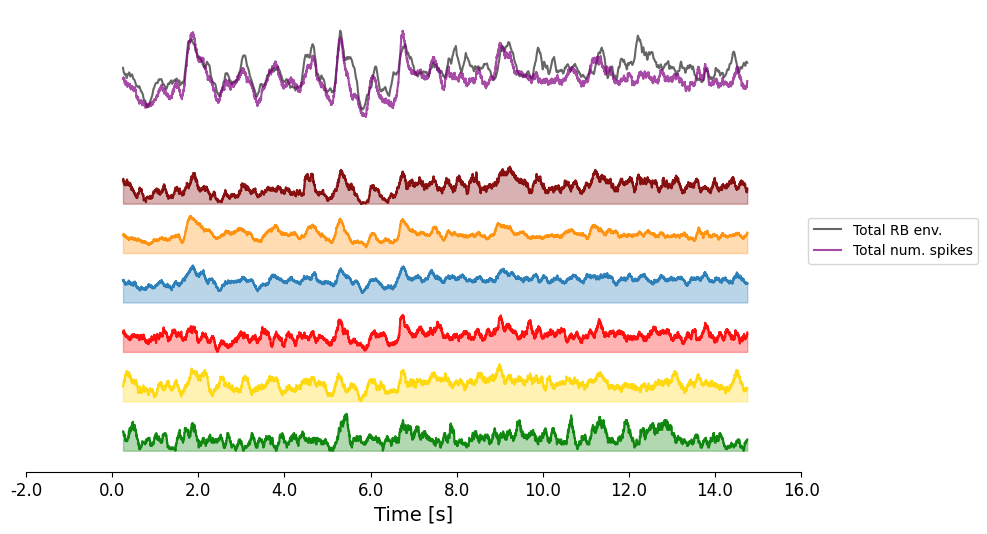

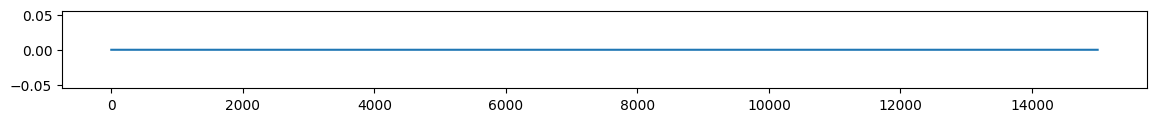

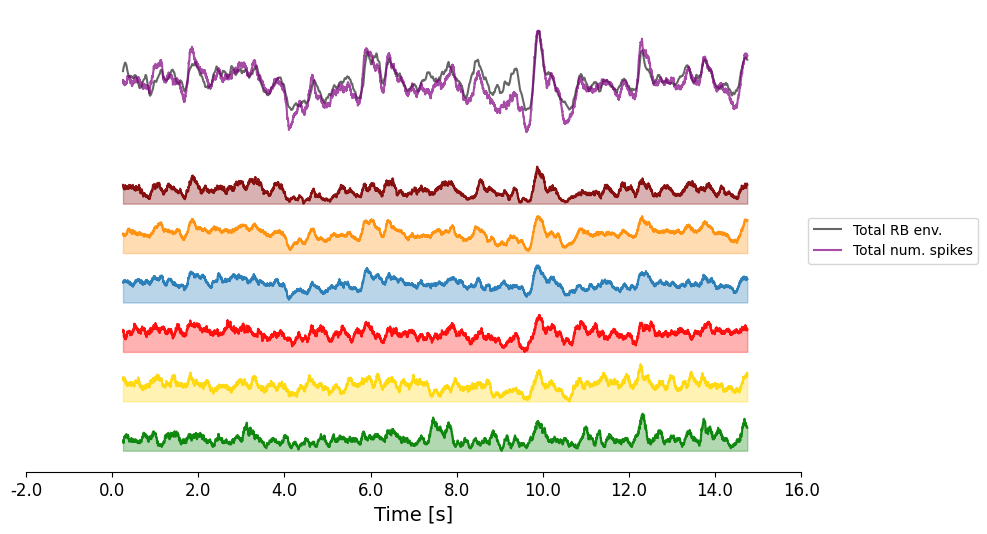

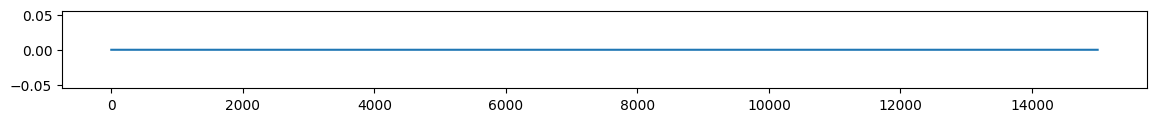

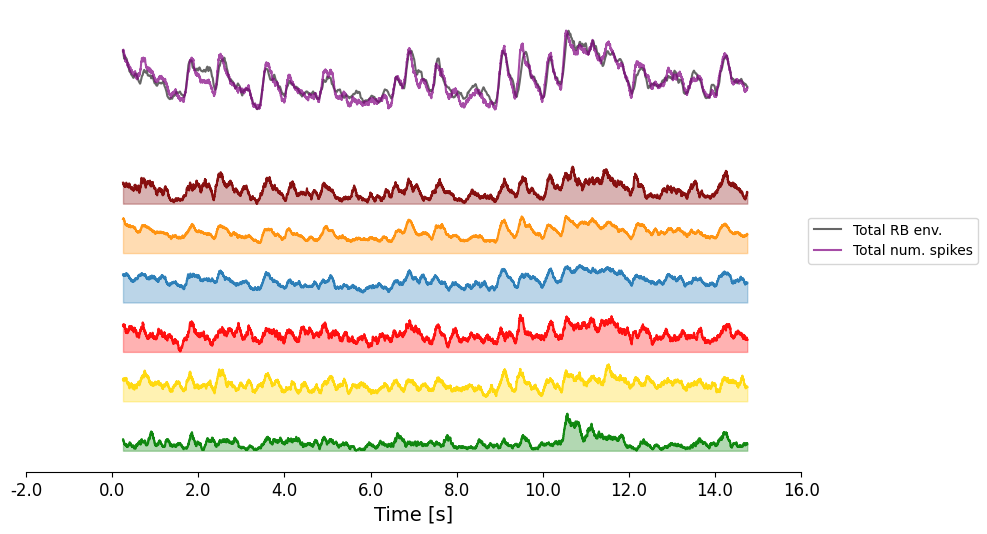

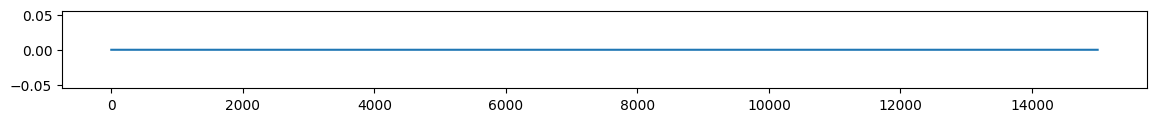

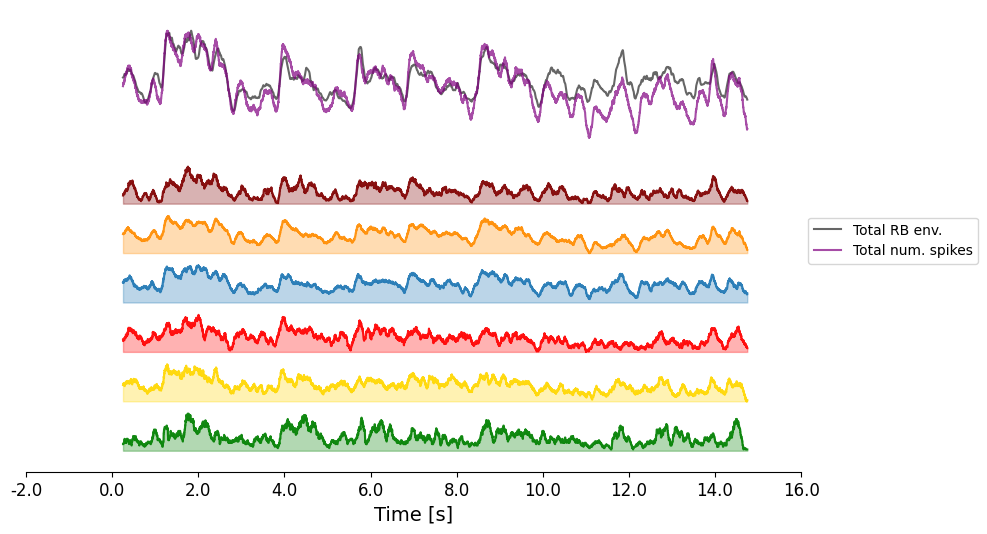

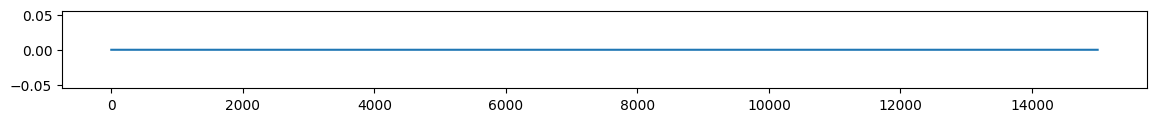

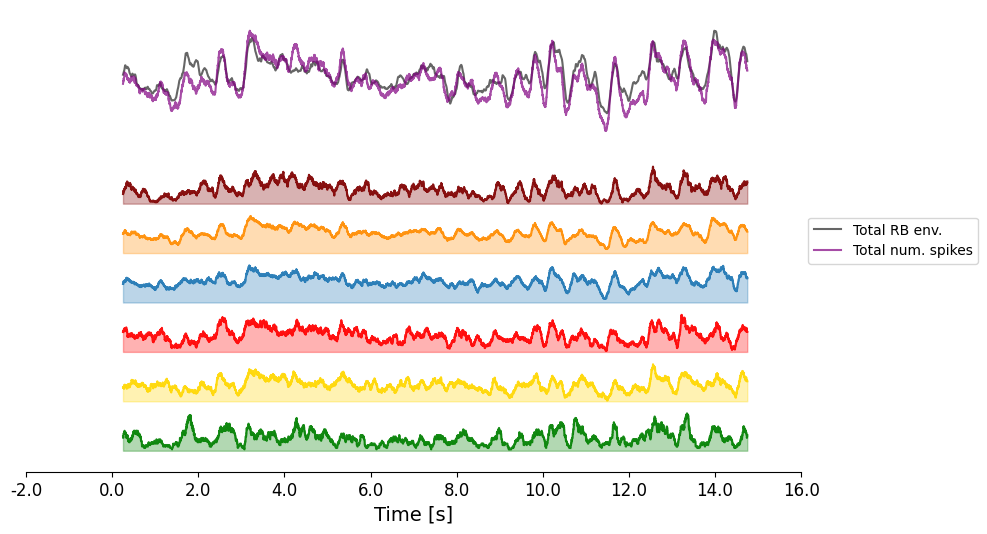

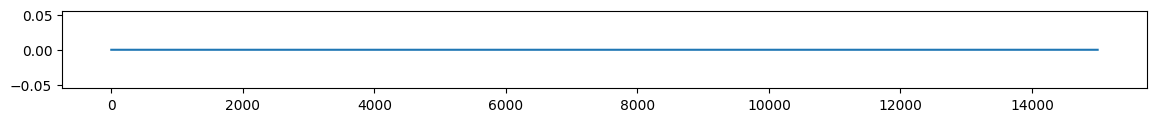

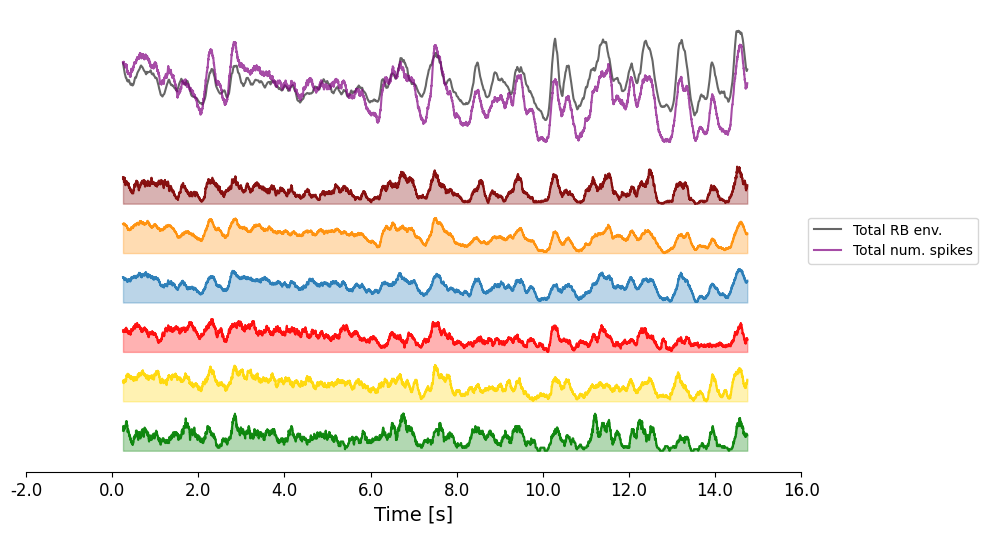

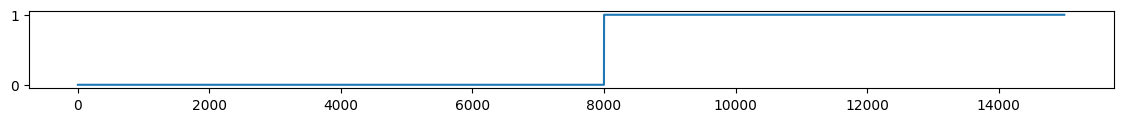

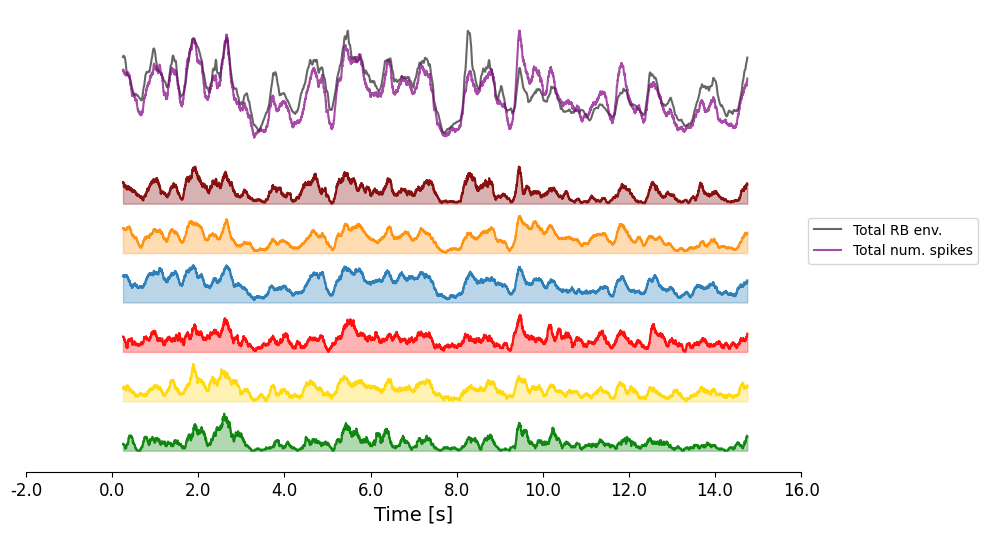

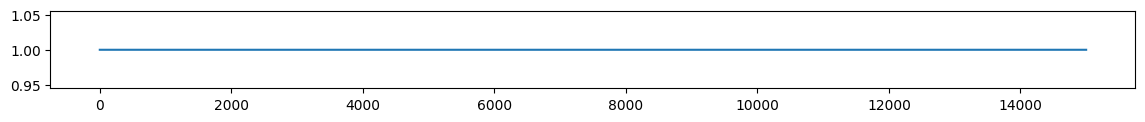

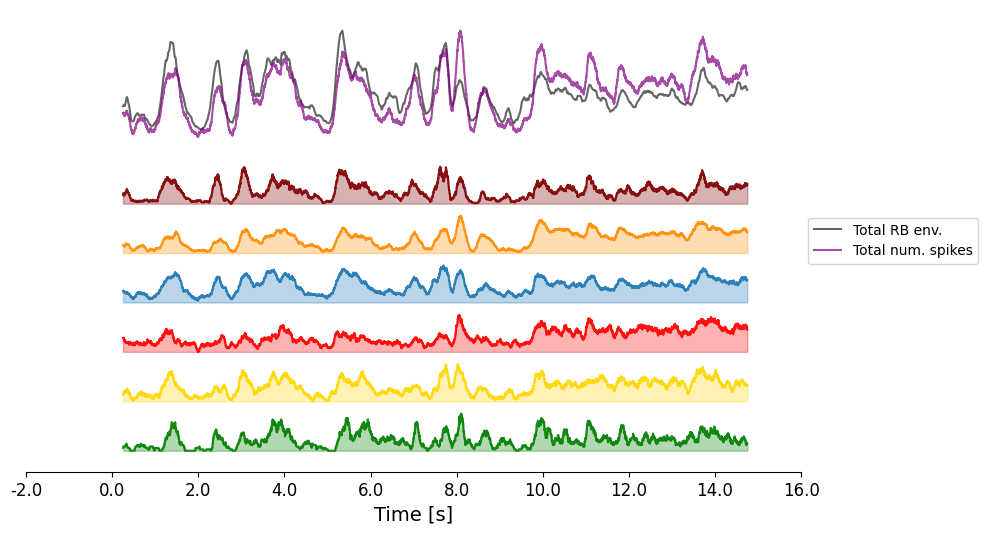

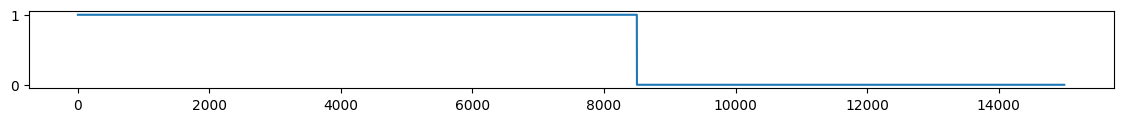

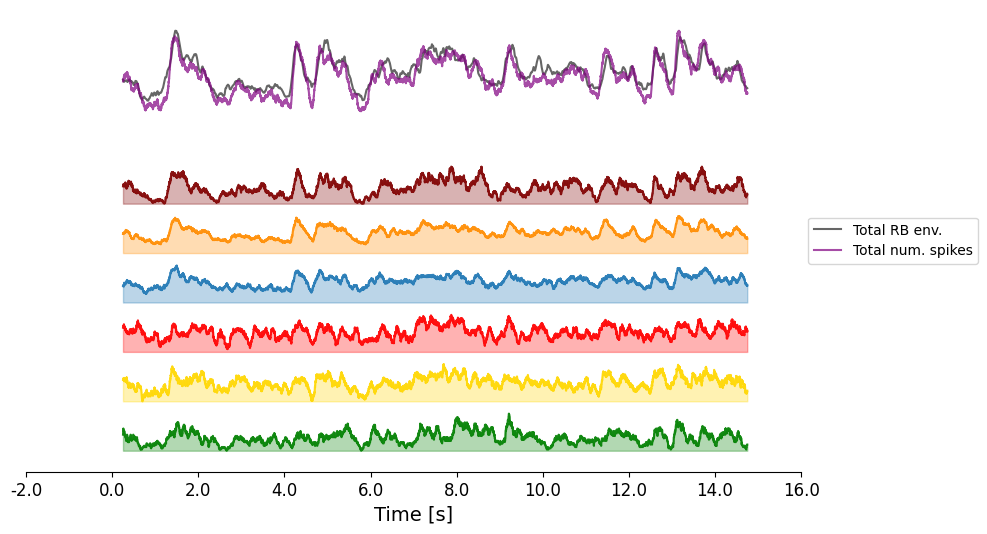

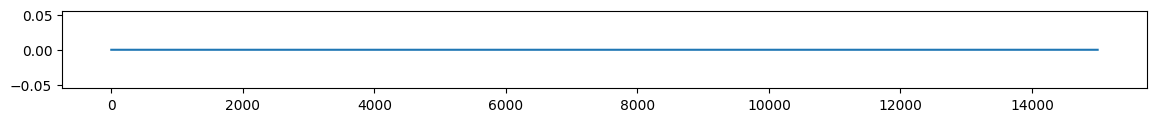

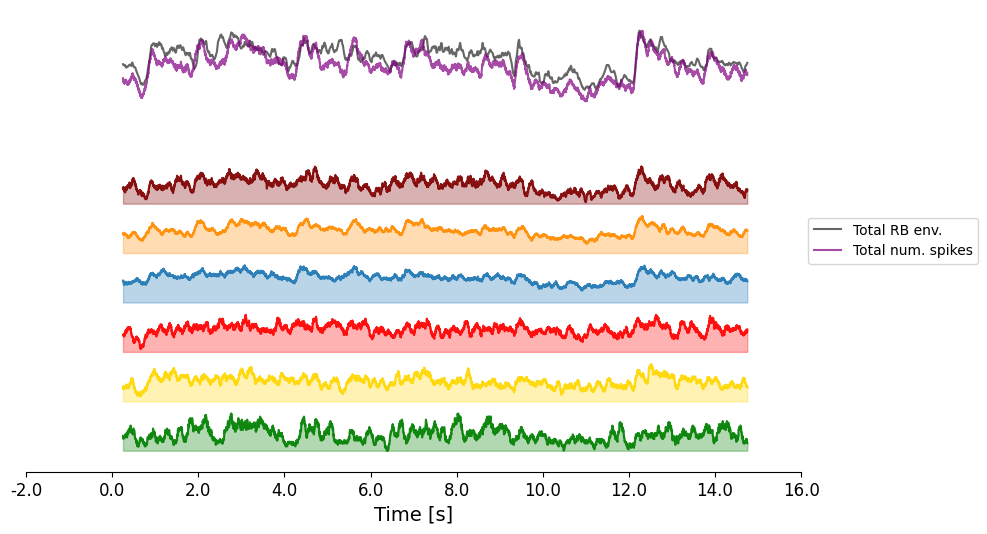

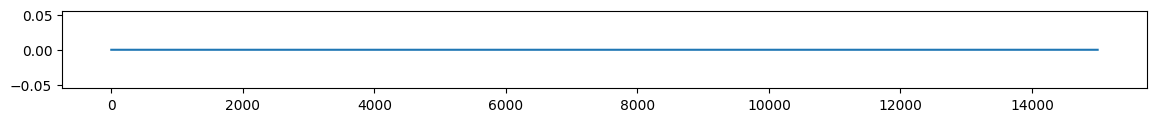

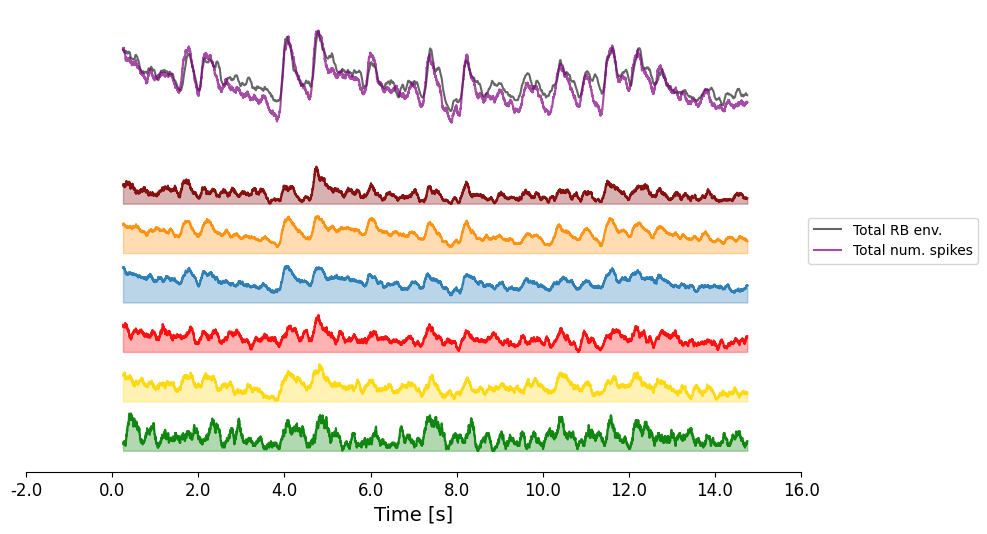

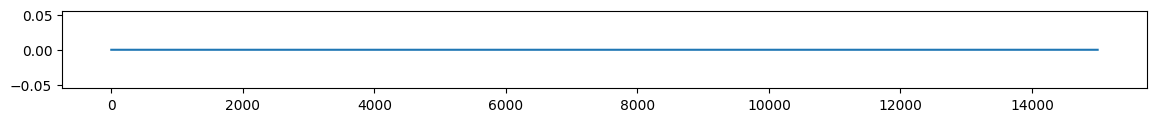

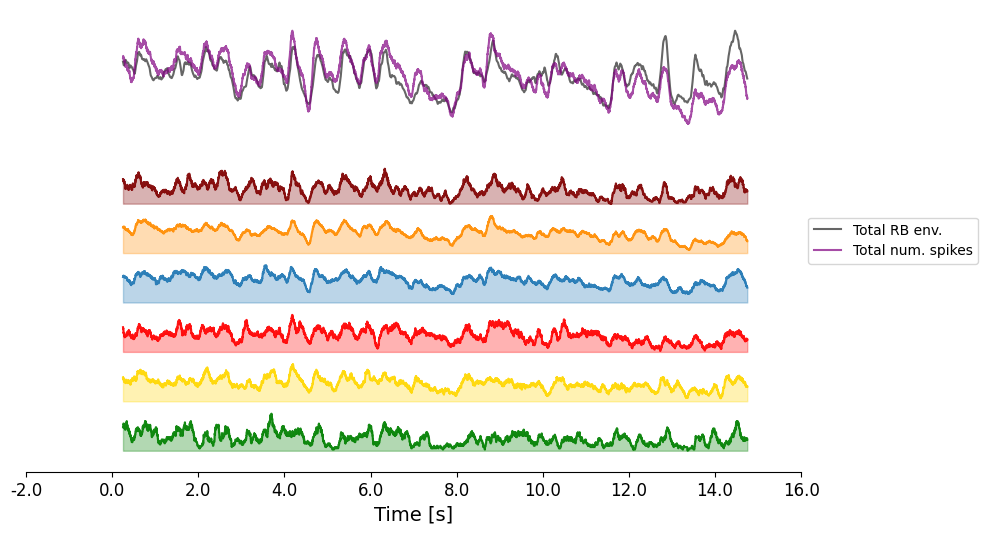

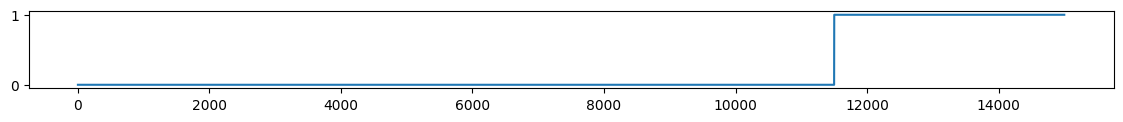

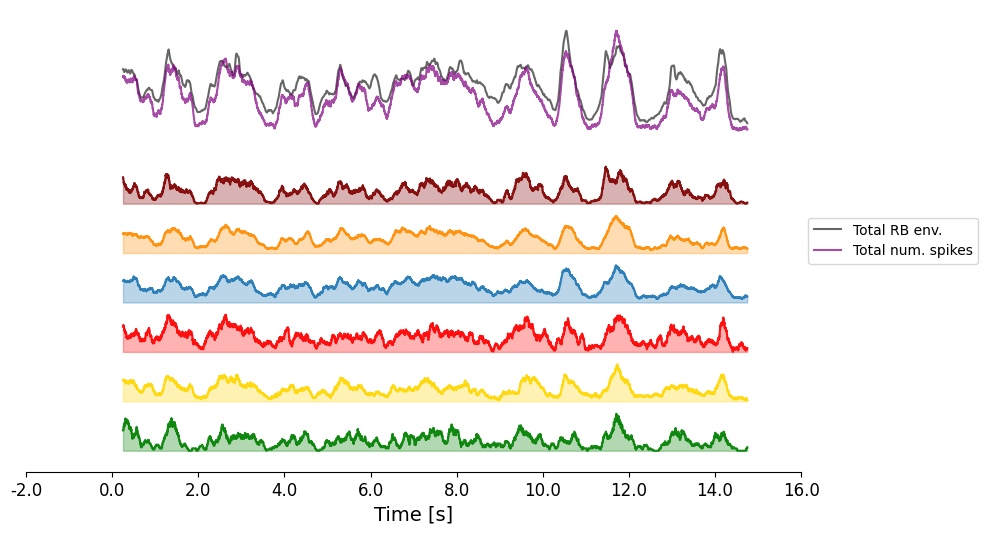

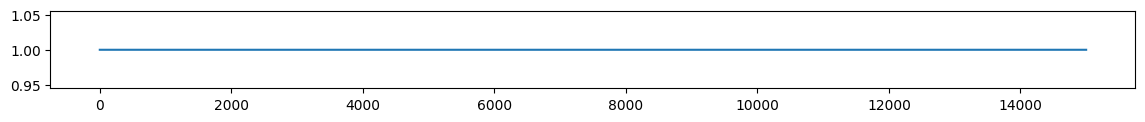

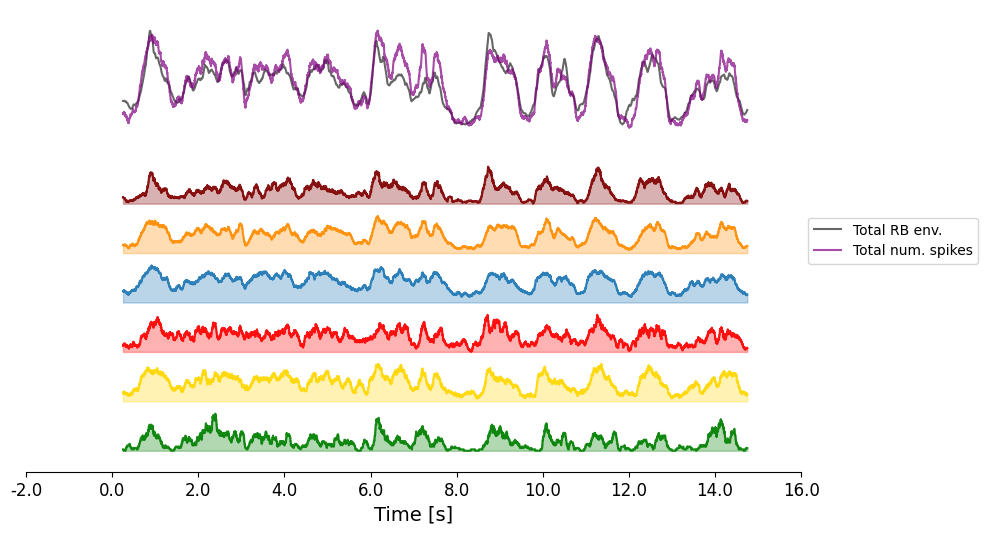

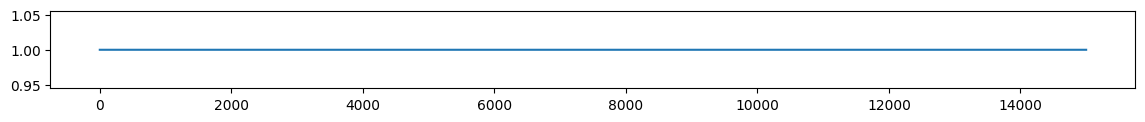

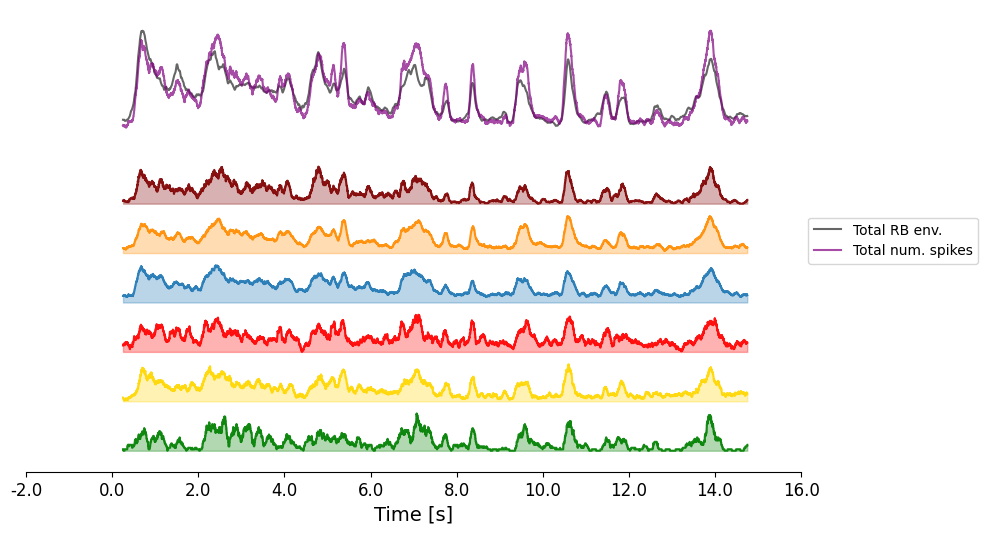

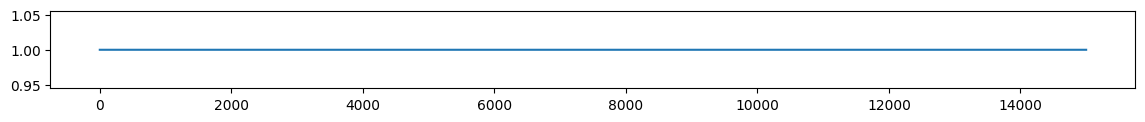

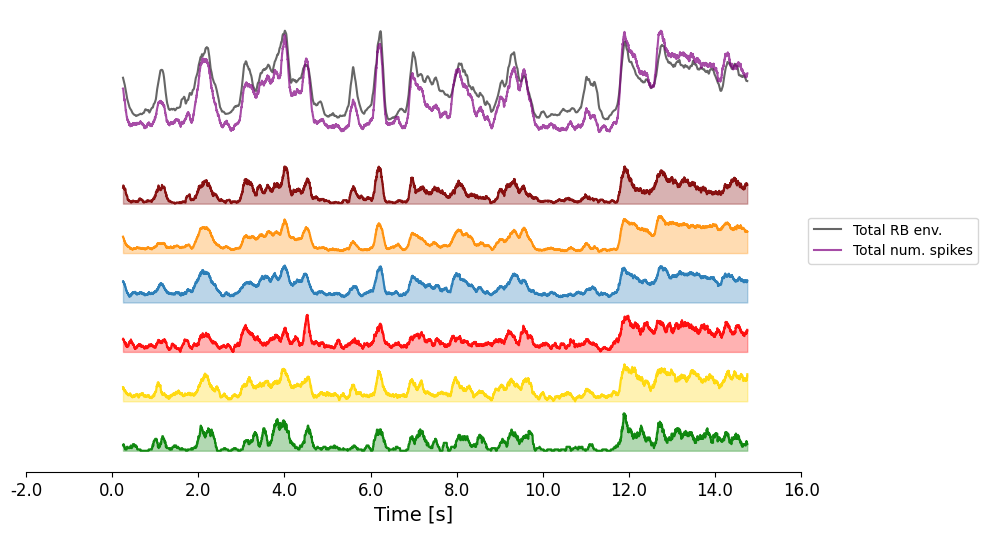

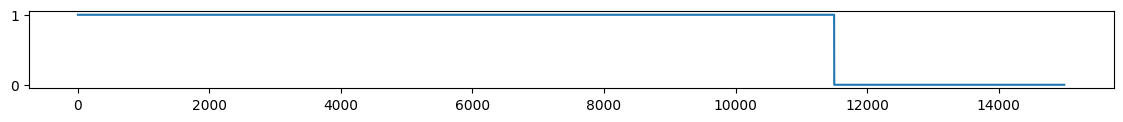

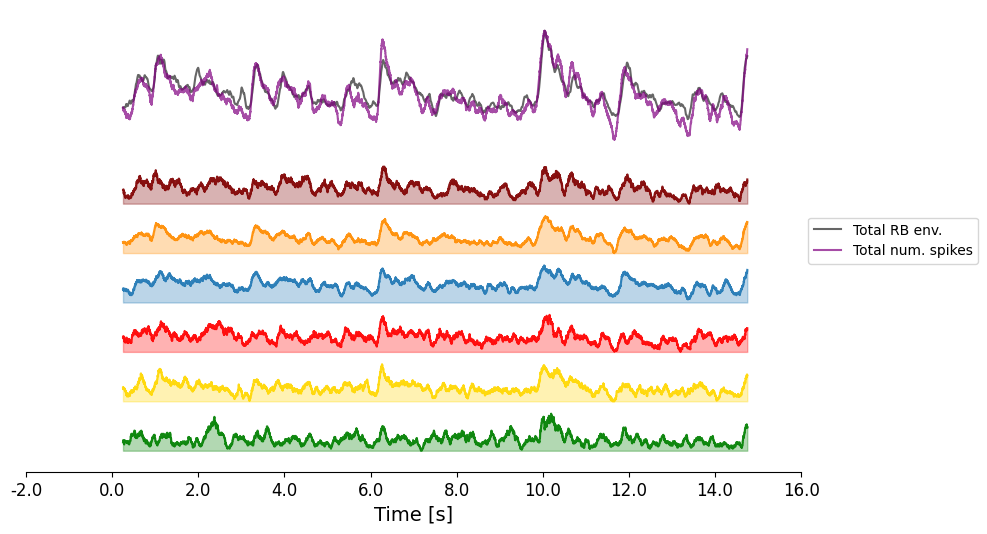

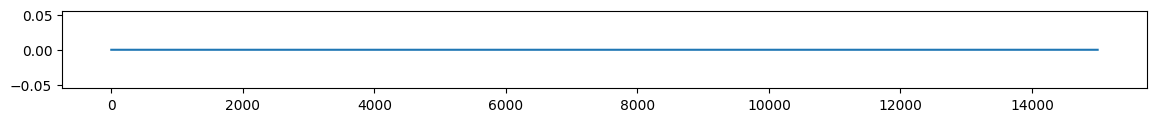

In [17]:
for i in range(20):
    start_idx = i*WIN_WIDTH
    stop_idx = (i+1)*WIN_WIDTH
    plot_example_activity(env_arr[:,start_idx:stop_idx],spikes_arr[:,start_idx:stop_idx],cl_arr,set_params)
    
    # plotting the EC indicator just for info
    file_path = f'/CSNG/studekat/ripple_paper_clean_copy/metadata/EC_EO_indicators/eyes_indic_monkey_{MONKEY}_RS_date_{DATE}_common_times.pkl'
    with open(file_path, 'rb') as file:
        eyes_dict = pickle.load(file)
    EC_indic = eyes_dict['EC']
    
    fig, ax = plt.subplots()
    fig.set_figwidth(14)
    fig.set_figheight(1)

    plt.plot(EC_indic[start_idx:stop_idx])

    plt.show()
    plt.close()

## Correlation RB env. and spikes

In [18]:
EC_all_corr_lists = []
EO_all_corr_lists = []
for monkey in MONKEY_LIST:
    print(monkey)
    for date in DATES[monkey]['RS']:
        print(date)
        for arr in range(1,17):
            try:
                if AREAS[monkey][arr-1] in ['V1','V2']:
                    print(arr)
                    # RB envelope
                    aux_bl = load_block(monkey,arr,'RS','RB',date,data_folder=DATA_FOLDER)
                    aux_env = sig_block_to_arr(aux_bl,'RB_envelope_norm')
                    t_start_arr = np.int64(aux_bl.segments[0].t_start)
                    aux_env = elephant.signal_processing.butter(aux_env, highpass_frequency=None, lowpass_frequency=40, 
                                                        order=6, filter_function='sosfiltfilt',sampling_frequency=1000, axis=-1)
                    # renormalize, because we filtered again
                    aux_env = aux_env/aux_env.std(axis=1,keepdims=True)
                    # EC and EO
                    file_path = f'/CSNG/studekat/ripple_paper_clean_copy/metadata/EC_EO_indicators/eyes_indic_monkey_{monkey}_RS_date_{date}_common_times.pkl'
                    with open(file_path, 'rb') as file:
                        eyes_dict = pickle.load(file)
                    aux_env = cut_abs_times(aux_env,t_start_arr,monkey,rec_type='RS',date=date,params=params_analysis)
                    # spikes
                    aux_bl = load_block(monkey,arr,'RS','spikes_KS4_filtered',date,data_folder=DATA_FOLDER)
                    aux_sp_arr = spike_block_to_arr(aux_bl)
                    aux_sp_arr = cut_abs_times(aux_sp_arr,t_start_arr,monkey,rec_type='RS',date=date,params=params_analysis)
                    # eyes masks
                    EC_mask = eyes_dict['EC'].astype(bool)
                    EO_mask = eyes_dict['EO'].astype(bool)
                    #print([EC_mask.shape[0],aux_env.shape[1],aux_sp_arr.shape[1]])
                    min_len = np.min([EC_mask.shape[0],aux_env.shape[1],aux_sp_arr.shape[1]])
                    # cutting away 1 ms differences that sometimes occur
                    EC_mask = EC_mask[:min_len]
                    EO_mask = EO_mask[:min_len]
                    aux_env = aux_env[:,:min_len]
                    aux_sp_arr = aux_sp_arr[:,:min_len]
                    # correlation list EC
                    aux_corr_list = corr_list_one_arr(aux_env[:,EC_mask],aux_sp_arr[:,EC_mask],bin_size=10,num_bins_win=100)
                    EC_all_corr_lists.append(aux_corr_list)
                    aux_corr_list = corr_list_one_arr(aux_env[:,EO_mask],aux_sp_arr[:,EO_mask],bin_size=10,num_bins_win=100)
                    EO_all_corr_lists.append(aux_corr_list)  
            except:
                print(f'For array {arr} the data were not processed.')

L
20170725
1
4
5
6
7
8
9
10
11
12
13
14
15
16
20170809
1
4
5
6
7
8
9
10


/home/studekat/virt_env/work/lib/python3.12/site-packages/elephant/conversion.py:1130: UserWarning: Binning discarded 1 last spike(s) of the input spiketrain
  warnings.warn("Binning discarded {} last spike(s) of the "


11
12
13
14
15
16
20170810
1
4
5
6
7
8
9
10
11
12
13
14
15
16
N
20240719_B1
1
2
3
4
6
7
8
20240719_B2
1
2
3
4
6
7
8
F
20240122_B1
1
2
3
4
5
6
7
8
20241216_B1
1
2
3
4
5
6
7
8


In [19]:
EO_all_corr = np.array(list_merge(EO_all_corr_lists))
EC_all_corr = np.array(list_merge(EC_all_corr_lists))

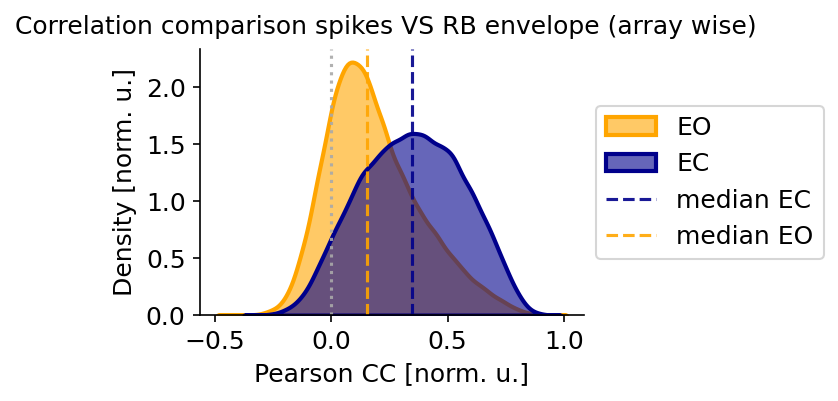

In [20]:
fig, ax = plt.subplots(dpi=150)
fig.set_figwidth(3.3)
fig.set_figheight(2.3)

plt.suptitle('Correlation comparison spikes VS RB envelope (array wise)')

sns.kdeplot(EO_all_corr, ax=ax, fill=True, color='orange', linewidth=2,alpha=0.6,label='EO')
sns.kdeplot(EC_all_corr, ax=ax, fill=True, color='darkblue', linewidth=2,alpha=0.6,label='EC')
ax.axvline(np.median(EC_all_corr),color='darkblue',ls='dashed',alpha=0.9,label='median EC')
ax.axvline(np.median(EO_all_corr),color='orange',ls='dashed',alpha=0.9,label='median EO')
ax.axvline(0,alpha=0.9,color='darkgray',ls=':')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('Density [norm. u.]',fontsize=12)
ax.set_xlabel('Pearson CC [norm. u.]',fontsize=12)
ax.tick_params(axis='both', labelsize=12)


ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize=12)
plt.show()
plt.close()

In [21]:
stat, p = mannwhitneyu(EC_all_corr, EO_all_corr, alternative='two-sided')
print(p)

0.0


In [22]:
print(len(EC_all_corr))
print(len(EO_all_corr))

43341
37714


## Examples of phase locked transient spiking 

### Red 1

In [23]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 6
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_medium_sharp
1 DOWN_medium_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_narrow_sharp
5 DOWN_narrow_sharp
6 DOWN_narrow_sharp
7 DOWN_narrow_sharp
8 DOWN_narrow_sharp
9 DOWN_narrow_sharp
10 DOWN_narrow_sharp
11 DOWN_narrow_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_medium_shallow


In [24]:
cell_idx = 7
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 22
Cell idx: 7, DOWN_narrow_sharp, channel: 19


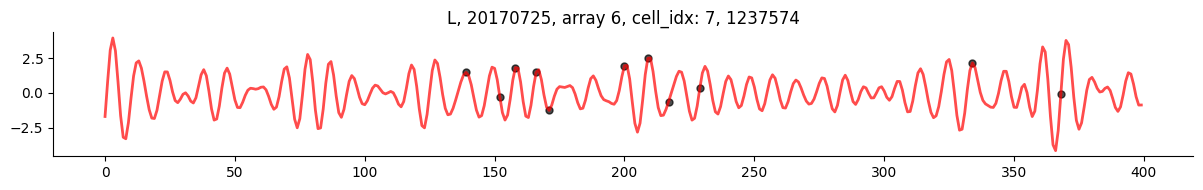

In [25]:
for spike in spikes_leading:
    if spike==1237574:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Red 2

In [26]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 6
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_medium_sharp
1 DOWN_medium_sharp
2 DOWN_medium_sharp
3 DOWN_medium_sharp
4 DOWN_narrow_sharp
5 DOWN_narrow_sharp
6 DOWN_narrow_sharp
7 DOWN_narrow_sharp
8 DOWN_narrow_sharp
9 DOWN_narrow_sharp
10 DOWN_narrow_sharp
11 DOWN_narrow_sharp
12 DOWN_medium_shallow
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_shallow
17 DOWN_medium_shallow
18 DOWN_medium_shallow
19 DOWN_narrow_shallow
20 DOWN_medium_shallow
21 DOWN_medium_shallow


In [27]:
cell_idx = 10
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 22
Cell idx: 10, DOWN_narrow_sharp, channel: 19


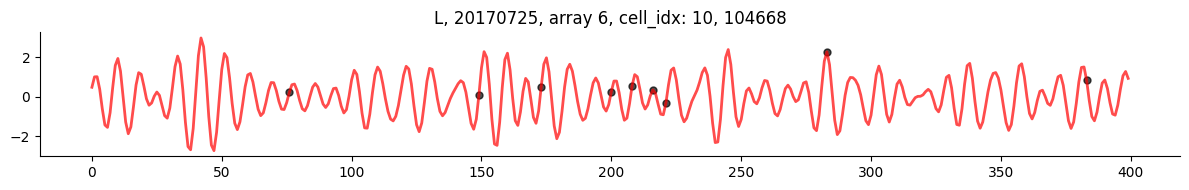

In [28]:
for spike in spikes_leading:
    if spike==104668:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        if shift>0:
            mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
            spikes_cut = spike_idx[mask]
            plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
        
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            plt.tight_layout()
            plt.show()
            plt.close()

### Blue 1

In [29]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 14
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_narrow_shallow
1 DOWN_wide
2 DOWN_medium_shallow
3 DOWN_medium_shallow
4 DOWN_medium_shallow
5 DOWN_medium_shallow
6 DOWN_medium_shallow
7 DOWN_medium_shallow
8 DOWN_wide
9 DOWN_wide
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_wide
13 DOWN_medium_shallow


In [30]:
cell_idx = 8
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 14
Cell idx: 8, DOWN_wide, channel: 30


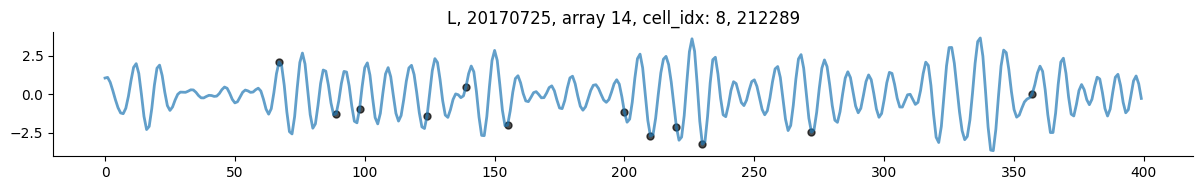

In [31]:
for spike in spikes_leading:
    if spike==212289:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Blue 2

In [32]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_wide
1 DOWN_wide
2 DOWN_narrow_sharp
3 DOWN_wide
4 DOWN_wide
5 DOWN_medium_sharp
6 DOWN_medium_sharp
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_wide
10 DOWN_wide
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 UP
14 DOWN_medium_sharp
15 UP
16 DOWN_wide
17 DOWN_wide
18 DOWN_medium_sharp
19 DOWN_medium_shallow
20 DOWN_wide
21 DOWN_medium_sharp
22 DOWN_wide
23 DOWN_wide
24 DOWN_medium_sharp
25 DOWN_medium_sharp
26 UP
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
31 DOWN_narrow_sharp
32 DOWN_wide
33 DOWN_wide


In [33]:
cell_idx = 0
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 34
Cell idx: 0, DOWN_wide, channel: 9


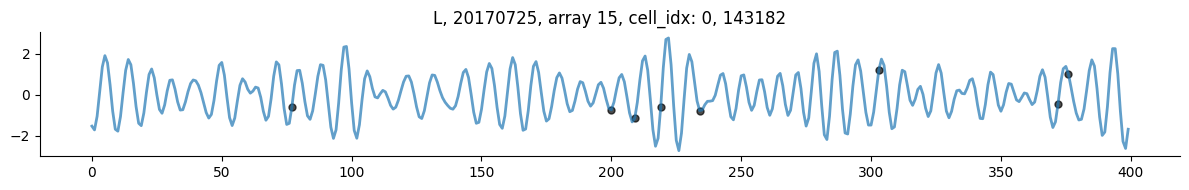

In [34]:
for spike in spikes_leading:
    if spike==143182:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Yellow 1

In [35]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_wide
1 DOWN_wide
2 DOWN_narrow_sharp
3 DOWN_wide
4 DOWN_wide
5 DOWN_medium_sharp
6 DOWN_medium_sharp
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_wide
10 DOWN_wide
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 UP
14 DOWN_medium_sharp
15 UP
16 DOWN_wide
17 DOWN_wide
18 DOWN_medium_sharp
19 DOWN_medium_shallow
20 DOWN_wide
21 DOWN_medium_sharp
22 DOWN_wide
23 DOWN_wide
24 DOWN_medium_sharp
25 DOWN_medium_sharp
26 UP
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
31 DOWN_narrow_sharp
32 DOWN_wide
33 DOWN_wide


In [36]:
cell_idx = 6
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 34
Cell idx: 6, DOWN_medium_sharp, channel: 14


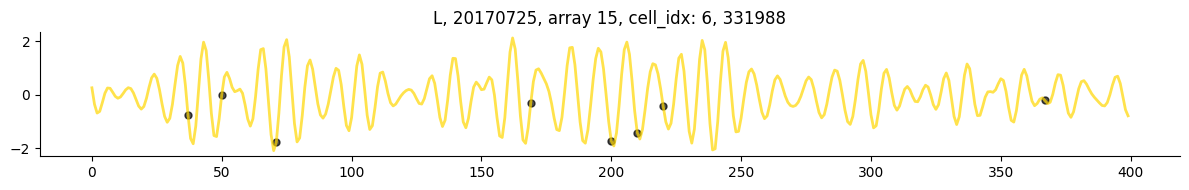

In [37]:
for spike in spikes_leading:
    if spike==331988:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Yellow 2

In [38]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 4
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170809
V1
0 DOWN_medium_sharp
1 DOWN_wide
2 DOWN_wide
3 DOWN_medium_shallow
4 DOWN_medium_sharp
5 DOWN_wide
6 DOWN_wide
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_medium_sharp
10 DOWN_medium_shallow
11 UP
12 DOWN_narrow_shallow
13 UP
14 DOWN_narrow_sharp
15 DOWN_wide
16 DOWN_medium_sharp
17 DOWN_medium_sharp
18 DOWN_medium_sharp
19 DOWN_medium_sharp
20 DOWN_wide
21 DOWN_medium_sharp
22 DOWN_wide
23 DOWN_narrow_sharp
24 DOWN_medium_sharp
25 DOWN_medium_shallow
26 DOWN_medium_sharp
27 DOWN_medium_sharp
28 DOWN_wide
29 DOWN_medium_sharp
30 DOWN_narrow_sharp
31 DOWN_medium_shallow
32 DOWN_medium_sharp
33 DOWN_medium_sharp
34 DOWN_medium_sharp
35 DOWN_medium_shallow
36 DOWN_medium_shallow
37 DOWN_wide


In [39]:
cell_idx = 7
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 38
Cell idx: 7, DOWN_medium_sharp, channel: 16


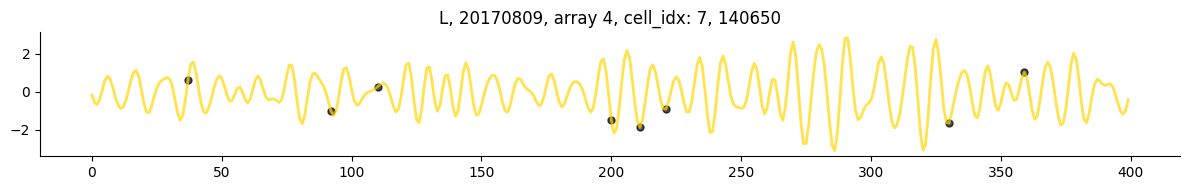

In [40]:
for spike in spikes_leading:
    if spike==140650:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Maroon 1

In [41]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 7
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170809
V1
0 DOWN_wide
1 DOWN_narrow_shallow
2 DOWN_wide
3 DOWN_narrow_shallow
4 DOWN_medium_sharp
5 DOWN_narrow_shallow
6 DOWN_medium_shallow
7 DOWN_wide
8 DOWN_wide
9 DOWN_medium_sharp
10 DOWN_narrow_shallow
11 DOWN_wide
12 UP
13 DOWN_wide
14 DOWN_narrow_sharp
15 DOWN_narrow_shallow
16 DOWN_narrow_sharp
17 DOWN_narrow_shallow
18 DOWN_medium_shallow
19 DOWN_medium_shallow
20 DOWN_wide


In [42]:
cell_idx = 1
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 21
Cell idx: 1, DOWN_narrow_shallow, channel: 3


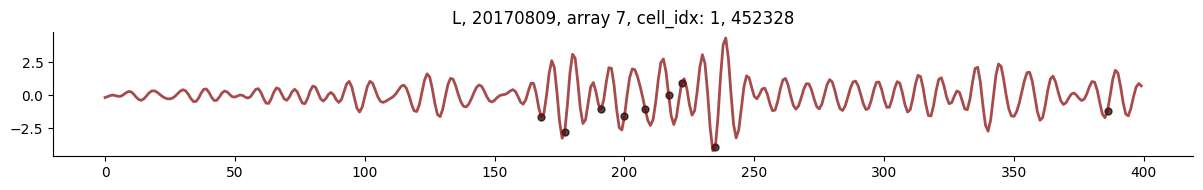

In [43]:
for spike in spikes_leading:
    if spike==452328:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Maroon 2

In [44]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 7
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170809
V1
0 DOWN_wide
1 DOWN_narrow_shallow
2 DOWN_wide
3 DOWN_narrow_shallow
4 DOWN_medium_sharp
5 DOWN_narrow_shallow
6 DOWN_medium_shallow
7 DOWN_wide
8 DOWN_wide
9 DOWN_medium_sharp
10 DOWN_narrow_shallow
11 DOWN_wide
12 UP
13 DOWN_wide
14 DOWN_narrow_sharp
15 DOWN_narrow_shallow
16 DOWN_narrow_sharp
17 DOWN_narrow_shallow
18 DOWN_medium_shallow
19 DOWN_medium_shallow
20 DOWN_wide


In [45]:
cell_idx = 1
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 21
Cell idx: 1, DOWN_narrow_shallow, channel: 3


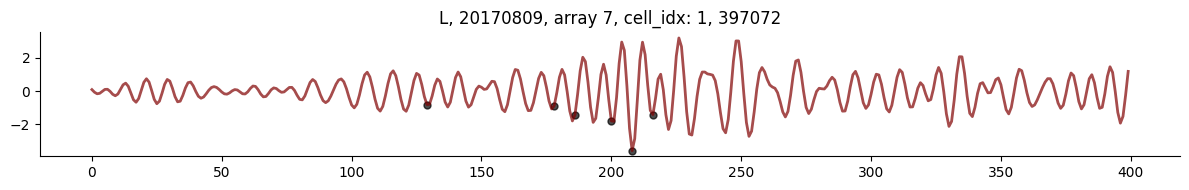

In [46]:
for spike in spikes_leading:
    if spike==397072:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Green 1

In [47]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 5
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170809
V1
0 DOWN_narrow_sharp
1 DOWN_narrow_sharp
2 DOWN_medium_shallow
3 DOWN_wide
4 DOWN_medium_shallow
5 UP
6 DOWN_medium_shallow
7 DOWN_medium_shallow
8 DOWN_medium_shallow
9 DOWN_medium_shallow
10 DOWN_medium_shallow
11 DOWN_medium_shallow
12 DOWN_wide
13 DOWN_medium_shallow
14 DOWN_medium_shallow
15 DOWN_medium_shallow
16 DOWN_medium_sharp


In [48]:
cell_idx = 5
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 17
Cell idx: 5, UP, channel: 20


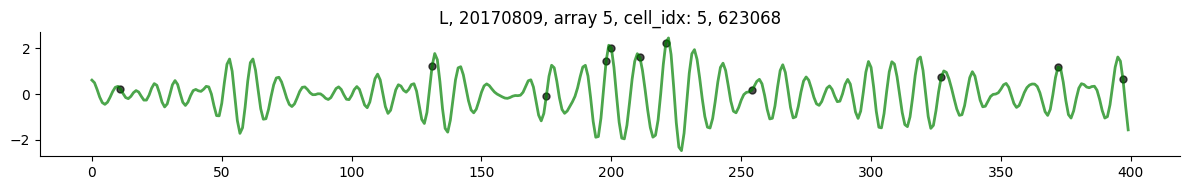

In [49]:
for spike in spikes_leading:
    if spike==623068:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Green 2

In [50]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][1]
print(DATE)
ARRAY = 6
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170809
V1
0 DOWN_medium_sharp
1 DOWN_narrow_sharp
2 DOWN_narrow_sharp
3 DOWN_medium_sharp
4 DOWN_narrow_sharp
5 DOWN_wide
6 DOWN_wide
7 DOWN_wide
8 DOWN_medium_sharp
9 DOWN_medium_sharp
10 DOWN_wide
11 DOWN_narrow_sharp
12 DOWN_medium_sharp
13 DOWN_narrow_sharp
14 DOWN_narrow_sharp
15 DOWN_narrow_sharp
16 UP
17 DOWN_medium_sharp
18 DOWN_medium_sharp
19 DOWN_wide
20 DOWN_medium_shallow
21 DOWN_narrow_shallow
22 DOWN_medium_shallow
23 DOWN_medium_shallow
24 DOWN_wide


In [51]:
cell_idx = 16
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 25
Cell idx: 16, UP, channel: 19


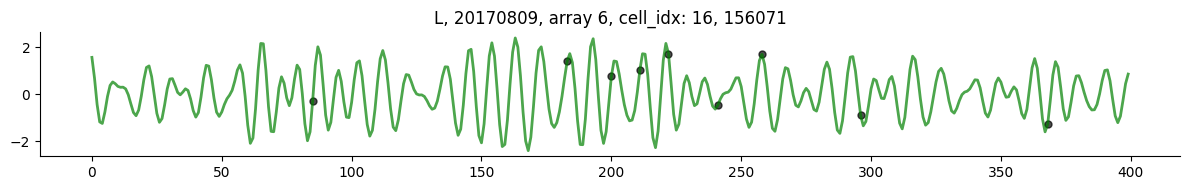

In [52]:
for spike in spikes_leading:
    if spike==156071:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Orange 1

In [53]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_wide
1 DOWN_wide
2 DOWN_narrow_sharp
3 DOWN_wide
4 DOWN_wide
5 DOWN_medium_sharp
6 DOWN_medium_sharp
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_wide
10 DOWN_wide
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 UP
14 DOWN_medium_sharp
15 UP
16 DOWN_wide
17 DOWN_wide
18 DOWN_medium_sharp
19 DOWN_medium_shallow
20 DOWN_wide
21 DOWN_medium_sharp
22 DOWN_wide
23 DOWN_wide
24 DOWN_medium_sharp
25 DOWN_medium_sharp
26 UP
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
31 DOWN_narrow_sharp
32 DOWN_wide
33 DOWN_wide


In [54]:
cell_idx = 12
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 34
Cell idx: 12, DOWN_medium_shallow, channel: 23


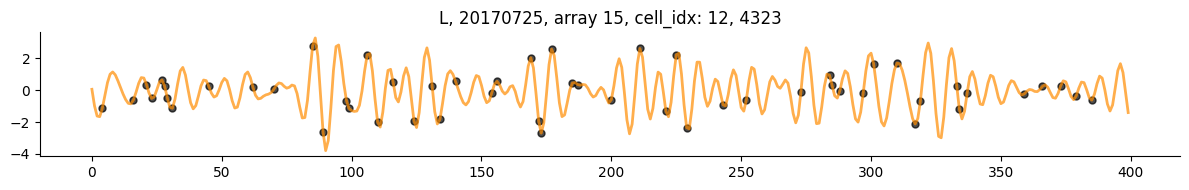

In [55]:
for spike in spikes_leading:
    if spike==4323:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()

### Orange 2

In [56]:
# Data loading
MONKEY = 'L'
DATE = DATES[MONKEY]['RS'][0]
print(DATE)
ARRAY = 15
print(AREAS[MONKEY][ARRAY])  # just to make sure I am not looking outside of V1 and V2 

## RB
rb_bl = load_block(MONKEY,ARRAY,'RS','RB',DATE,data_folder=DATA_FOLDER)
rb_arr = sig_block_to_arr(rb_bl,'RB_filtered_zsc')

## SUA
with open(f'{DF_FOLDER}/sua_prop_all/monkey{MONKEY}_all_arrays_date_{DATE}.pkl', "rb") as file:
    df_sua = pickle.load(file)
    
df_sua = df_sua[df_sua['array']==ARRAY]
spike_bl = load_block(MONKEY,ARRAY,'RS','spikes_KS4_filtered',DATE,data_folder=DATA_FOLDER)
spike_arr = spike_block_to_arr(spike_bl)

## find channels and cell classes
cell_classes = find_classes_cells(spike_bl,df_sua)
cell_classes = [str(s.iloc[0]) for s in cell_classes]
cell_channels = find_channels_cells(spike_bl,df_sua)
cell_channels = [s.iloc[0] for s in cell_channels]

for idx, cl in enumerate(cell_classes):
    print(idx, cl)

20170725
V1
0 DOWN_wide
1 DOWN_wide
2 DOWN_narrow_sharp
3 DOWN_wide
4 DOWN_wide
5 DOWN_medium_sharp
6 DOWN_medium_sharp
7 DOWN_medium_sharp
8 DOWN_wide
9 DOWN_wide
10 DOWN_wide
11 DOWN_medium_shallow
12 DOWN_medium_shallow
13 UP
14 DOWN_medium_sharp
15 UP
16 DOWN_wide
17 DOWN_wide
18 DOWN_medium_sharp
19 DOWN_medium_shallow
20 DOWN_wide
21 DOWN_medium_sharp
22 DOWN_wide
23 DOWN_wide
24 DOWN_medium_sharp
25 DOWN_medium_sharp
26 UP
27 DOWN_wide
28 DOWN_narrow_sharp
29 DOWN_narrow_sharp
30 DOWN_wide
31 DOWN_narrow_sharp
32 DOWN_wide
33 DOWN_wide


In [57]:
cell_idx = 12
cell_class = cell_classes[cell_idx]
cell_ch = cell_channels[cell_idx]
cell_color = CLASS_COLORS[cell_class]
spike_vec = spike_arr[cell_idx,:]
rb_vec = rb_arr[cell_ch,:]
spike_idx = np.where(spike_vec>0)[0]
print(f'Num. cells: {spike_arr.shape[0]}')
print(f'Cell idx: {cell_idx}, {cell_class}, channel: {cell_ch}')

_, spikes_leading = find_close_triplets(spike_idx)
spikes_leading = np.array(spikes_leading)

WIN_WIDTH = 200

Num. cells: 34
Cell idx: 12, DOWN_medium_shallow, channel: 23


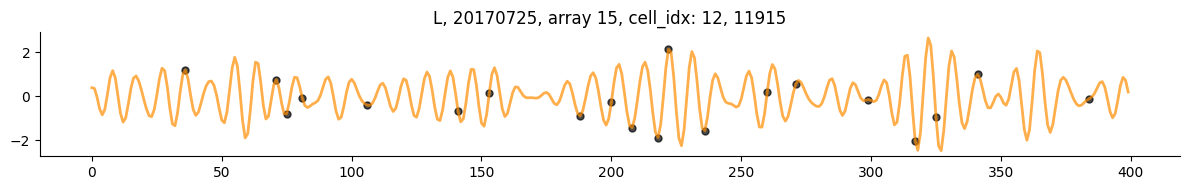

In [58]:
for spike in spikes_leading:
    if spike==11915:  # only plotting the one final picture
        fig, ax = plt.subplots()
        fig.set_figwidth(12)
        fig.set_figheight(2)
        
        plt.title(f'{MONKEY}, {DATE}, array {ARRAY}, cell_idx: {cell_idx}, {spike}')
    
        rb_cut = rb_vec[spike-WIN_WIDTH:spike+WIN_WIDTH]
        plt.plot(rb_cut,color=cell_color,alpha=0.7,linewidth=2)
        shift = spike - WIN_WIDTH  # shifting the position of the first spike to match the cut in the plot
        mask = (spike_idx>spike-WIN_WIDTH) & (spike_idx<spike+WIN_WIDTH)
        spikes_cut = spike_idx[mask]
        plt.scatter(spikes_cut-shift,rb_cut[spikes_cut - shift],color='k',s=25,alpha=0.7)
    
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        plt.close()